# Metrics Basics

## Setup

### Imports

In [1]:
# Shared Packages

# Local functions and classes
from utilities import *
from contour_plotting import *
from debug_tools import *


INFO:metrics.base:Registered calculator: orthogonal_margins (OrthogonalMarginsCalculator)
INFO:metrics.base:Registered calculator: minimum_margin (MinimumMarginCalculator)
INFO:metrics.base:Registered calculator: maximum_margin (MaximumMarginCalculator)
INFO:metrics.base:Registered calculator: minimum_distance (MinimumDistanceCalculator)


In [2]:
%matplotlib inline

## Algorithms

See: https://shapely.readthedocs.io/en/stable/measurement.html

### Bounds
`shapely.bounds(geometry, **kwargs)`

Compute the bounds (extent) of _each_ geometry.

For _each_ geometry these 4 numbers are returned: min x, min y, max x, max y.

**Parameters:**
> geometry
> - Geometry or array_like
> - Geometry or geometries for which to compute the bounds.

______________

`shapely.total_bounds(geometry, **kwargs)`

Compute the _total_ bounds (extent) of the combined geometries.
For a single geometry `shapely.bounds` and `shapely.total_bounds` will return identical results

**Parameters:**
> geometry
> - Geometry or array_like
> - Geometry or geometries for which to compute the total bounds.


In [3]:
print("Bounds calculates a bounding box for each geometry")
print("The result is a tuple or list of tuples of (minx, miny, maxx, maxy).")
print(shapely.bounds([
    shapely.LineString([(0, 1), (0, 2), (3, 2)]),
    shapely.LineString([(4, 4), (4, 6), (6, 7)])
]))
print("Total bounds calculates a bounding box that encompasses all geometries")
print("The result is a single tuple of (minx, miny, maxx, maxy).")
print(shapely.total_bounds([
    shapely.LineString([(0, 1), (0, 2), (3, 2)]),
    shapely.LineString([(4, 4), (4, 6), (6, 7)])
]))

Bounds calculates a bounding box for each geometry
The result is a tuple or list of tuples of (minx, miny, maxx, maxy).
[[0. 1. 3. 2.]
 [4. 4. 6. 7.]]
Total bounds calculates a bounding box that encompasses all geometries
The result is a single tuple of (minx, miny, maxx, maxy).
[0. 1. 6. 7.]


_____________

`minimum_bounding_radius(geometry, **kwargs)`

Compute the radius of the minimum bounding circle of an input geometry.

**Parameters:**
> geometry
> - Geometry or array_like
> - Geometry or geometries for which to compute the minimum bounding radius.


In [4]:
print("Minimum Bounding Radius is the radius of the smallest circle around a "
      "polygon. It can be used to estimate the maximum distance between any "
      "two points in a polygon for some shapes.")
box_width = 2
box2 = shapely.Polygon(box_points(width=box_width))
r_2b = shapely.minimum_bounding_radius(box2)
print(f"Maximum distance between any two points of a square of length {box_width}, "
      f"is along the diagonal {2 * r_2b:.2f}.")
triangle_2 = shapely.Polygon([(0, 0), (box_width, 0), (0, box_width)])
r_2t = shapely.minimum_bounding_radius(triangle_2)
print(f"Maximum distance between any two points of a right angle triangle with "
      f"a side length of  length {box_width}, is along the one of the two "
      f"sides ({box_width}), but Minimum Bounding Radius still gives a distance "
      f"of. {2 * r_2t:.2f}.")


Minimum Bounding Radius is the radius of the smallest circle around a polygon. It can be used to estimate the maximum distance between any two points in a polygon for some shapes.
Maximum distance between any two points of a square of length 2, is along the diagonal 2.83.
Maximum distance between any two points of a right angle triangle with a side length of  length 2, is along the one of the two sides (2), but Minimum Bounding Radius still gives a distance of. 2.83.


### Hausdorff distance
`shapely.hausdorff_distance(a, b, densify=None, **kwargs)`

Compute the discrete Hausdorff distance between two geometries.

The Hausdorff distance is a measure of similarity: it is the greatest distance between any point in A and the closest point in B. The discrete distance is an approximation of this metric: only vertices are considered. The parameter ‘densify’ makes this approximation less coarse by splitting the line segments between vertices before computing the distance.

**Parameters:**
> a, b
> - Geometry or array_like
> - Geometry or geometries to compute the distance between.

> densify
> - float or array_like, optional
> - The value of densify is required to be between 0 and 1.

-------

### Fréchet distance

`shapely.frechet_distance(a, b, densify=None, **kwargs)`

Compute the discrete Fréchet distance between two geometries.

The Fréchet distance is a measure of similarity: it is the greatest distance between any point in A and the closest point in B. The discrete distance is an approximation of this metric: only vertices are considered. The parameter ‘densify’ makes this approximation less coarse by splitting the line segments between vertices before computing the distance.

Fréchet distance sweep continuously along their respective curves and the direction of curves is significant. This makes it a better measure of similarity than Hausdorff distance for curve or surface matching.

**Parameters:**
> a, b
> - Geometry or array_like
> - Geometry or geometries to compute the distance between.

> densify
> - float or array_like, optional
> - The value of densify is required to be between 0 and 1.

The Hausdorff distance is the maximum distance of a contour to the nearest point in the other contour.


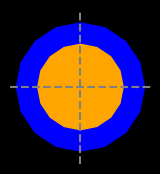

Hausdorff distance: 1.00
Frechet distance: 1.00
In this case this distance between rings is uniform.




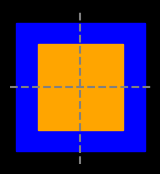

Hausdorff distance: 1.41
Frechet distance: 1.41
In this case the maximum distance is along the diagonal.


In [5]:
print("The Hausdorff distance is the maximum distance of a contour to the "
      "nearest point in the other contour.")

circle6 = shapely.Polygon(circle_points(3))
circle4 = shapely.Polygon(circle_points(2))
d_h = shapely.hausdorff_distance(circle6, circle4)
d_f = shapely.frechet_distance(circle6, circle4)
plot_ab(circle6, circle4)
print(f"Hausdorff distance: {d_h:.2f}")
print(f"Frechet distance: {d_f:.2f}")
print("In this case this distance between rings is uniform.\n\n")

box6 = shapely.Polygon(box_points(6))
box4 = shapely.Polygon(box_points(4))
d_h = shapely.hausdorff_distance(box6, box4)
d_f = shapely.frechet_distance(box6, box4)
plot_ab(box6, box4)
print(f"Hausdorff distance: {d_h:.2f}")
print(f"Frechet distance: {d_f:.2f}")
print("In this case the maximum distance is along the diagonal.")

## Distance
`shapely.distance(a, b, **kwargs)`

Compute the Cartesian distance between two geometries.

**Parameters:**
> a, b
> - Geometry or array_like
> - Geometry or geometries to compute the distance between.


### Area
`shapley.area(geometry, **kwargs)`

Compute the area of a (multi)polygon.

**Parameters:**
> geometry
> - Geometry or array_like
> - Geometry or geometries for which to compute the area.


### Length
`shapely.length(geometry, **kwargs)`

Compute the length of a (multi)linestring or polygon perimeter.

**Parameters:**
> geometry
> - Geometry or array_like
> - Geometry or geometries for which to compute the length.


### Minimum Clearance
`shapely.minimum_clearance(geometry, **kwargs)`

Compute the Minimum Clearance distance.

A geometry’s “minimum clearance” is the smallest distance by which a vertex of the geometry could be moved to produce an invalid geometry.

If no minimum clearance exists for a geometry (for example, a single point, or an empty geometry), infinity is returned.

**Parameters:**
> geometry
> - Geometry or array_like
> - Geometry or geometries for which to compute the minimum clearance.


## Metric Definitions

### Distance
The Distance metric is the distance between two structures, which is the
minimum distance between any point on the contour of one structure to any point
on the contour of the other structure. On a given slice, this can be calculated
using the Shapely `distance` function.
> $Distance = distance(a,b)$

In the Z direction it is the distance between the closest boundary slices of
$a$ and $b$
> $\Delta Z$

#### Calculation
For the entire structure, the distance is the minimum of the 2D distance and the Z distance:
> $Distance = min( distance(a,b), \Delta Z )$

#### Usage
The Distance metric is well defined for two structures that do not overlap:
- DISJOINT
- SURROUNDS
- SHELTERS

For structures that touch each other (BORDERS), the distance is zero.

For structures that overlap in any way (OVERLAPS, CONTAINS etc.), the distance
is undefined (`NaN`).


#### Examples

##### Disjoint polygons on a plane

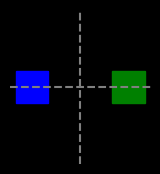

Box Bounds:
	Box A: (-4.0, -1.0, -2.0, 1.0)
	Box B: (2.0, -1.0, 4.0, 1.0)
Distance between boxes is minimum of B minus the maximum of A: 4.0
Shapely distance: 4.0


In [6]:
# 2 2x2 boxes
box2a = shapely.Polygon(box_points(2, offset_x=-3))
box2b = shapely.Polygon(box_points(2, offset_x=3))
plot_ab(box2a, box2b)
print(f"Box Bounds:\n\tBox A: {box2a.bounds}\n\tBox B: {box2b.bounds}")
print(f"Distance between boxes is minimum of B minus the maximum of A: "
      f"{box2b.bounds[0] - box2a.bounds[2]}")
print("Shapely distance:", shapely.distance(box2a, box2b))


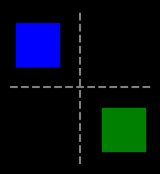

Box Coordinates:
	Box A: (-3.0, 1.0, -1.0, 3.0)
	Box B: (1.0, -3.0, 3.0, -1.0)
Distance between boxes is along the diagonal: 2.83
Shapely distance: 2.83


In [7]:
# 2 2x2 shifted boxes
box2a = shapely.Polygon(box_points(2, offset_x=-2, offset_y=2))
box2b = shapely.Polygon(box_points(2, offset_x=2, offset_y=-2))
plot_ab(box2a, box2b,dicom_orientation=False)
print(f"Box Coordinates:\n\tBox A: {box2a.bounds}\n\tBox B: {box2b.bounds}")
minx_a, miny_a, maxx_a, maxy_a = box2a.bounds
minx_b, miny_b, maxx_b, maxy_b = box2b.bounds
print(f"Distance between boxes is along the diagonal: "
      f"{sqrt((minx_b - maxx_a) ** 2 + (miny_a - maxy_b) ** 2):.2f}")
print(f"Shapely distance: {shapely.distance(box2a, box2b):.2f}")


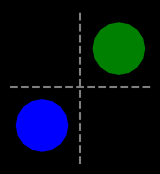

Box Coordinates:
	Box A: (-5.0, 1.0, -1.0, 5.0)
	Box B: (1.0, -5.0, 5.0, -1.0)
Distance between circle is the distance between there centres minus the circle diameters: 4.49
Shapely distance: 4.49


In [8]:
circle_diameter = 4
circle_a_centre = (-3, 3)
circle_b_centre = (3, -3)
circle_a = shapely.Polygon(circle_points(radius=circle_diameter/2,
                                         offset_x=circle_a_centre[0],
                                         offset_y=circle_a_centre[1]))
circle_b = shapely.Polygon(circle_points(radius=circle_diameter/2,
                                         offset_x=circle_b_centre[0],
                                         offset_y=circle_b_centre[1]))
plot_ab(circle_a, circle_b)
print(f"Box Coordinates:\n\tBox A: {circle_a.bounds}\n\tBox B: {circle_b.bounds}")
distance_between_centres = sqrt((circle_b_centre[0] - circle_a_centre[0]) ** 2 + (circle_a_centre[1] - circle_b_centre[1]) ** 2)
distance_between_circles = distance_between_centres - circle_diameter
print(f"Distance between circle is the distance between there centres minus the circle diameters: {distance_between_circles:.2f}")
print(f"Shapely distance: {shapely.distance(circle_a, circle_b):.2f}")


#### Surrounding / Surrounded structures

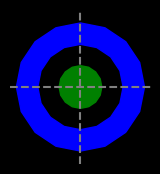

The Distance between the circle and the ring is the ring's inner radius minus the circle radius: 1.00
Shapely distance: 0.98
We are seeing a resolution effect here.


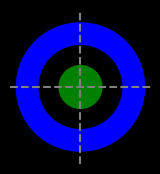

Shapely distance: 1.00
With a higher number of points the distance becomes correct.


In [9]:
circle6 = shapely.Polygon(circle_points(radius=3))
circle4 = shapely.Polygon(circle_points(radius=2))
circle2 = shapely.Polygon(circle_points(radius=1))

ring_a = circle6 - circle4
circle_b = circle2
plot_ab(ring_a, circle_b)
print(f"The Distance between the circle and the ring is the ring's inner radius minus the circle radius: {2 - 1:.2f}")
print(f"Shapely distance: {shapely.distance(ring_a, circle_b):.2f}")
print("We are seeing a resolution effect here.")

circle6 = shapely.Polygon(circle_points(radius=3, num_points=1000))
circle4 = shapely.Polygon(circle_points(radius=2, num_points=1000))
circle2 = shapely.Polygon(circle_points(radius=1, num_points=1000))
ring_a = circle6 - circle4
circle_b = circle2
plot_ab(ring_a, circle_b)
print(f"Shapely distance: {shapely.distance(ring_a, circle_b):.2f}")
print("With a higher number of points the distance becomes correct.")


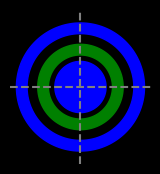

Distance between the outer ring (ring_a) and the inner ring (ring_b) is the inner radius of the ring_a minus the outer radius of the ring_b : 0.50
Shapely distance: 0.50


When the central circle is added to structure a, the distance between Structure A and Structure B (ring_b) becomes the distance between the inner radius of ring_b and the radius of the circle:0.30
Shapely distance: 0.30


In [10]:
circle6 = shapely.Polygon(circle_points(3, num_points=360))
circle5 = shapely.Polygon(circle_points(2.5, num_points=360))
circle4 = shapely.Polygon(circle_points(2, num_points=360))
circle3 = shapely.Polygon(circle_points(1.5, num_points=360))
circle2 = shapely.Polygon(circle_points(1.2, num_points=360))

ring_a = (circle6 - circle5)
ring_dot_a = ring_a.union(circle2)
ring_b = circle4 - circle3

plot_ab(ring_dot_a, ring_b)
print(f"Distance between the outer ring (ring_a) and the inner ring (ring_b) "
      f"is the inner radius of the ring_a minus the outer radius of the ring_b "
      f": {2.5 - 2:.2f}")
print(f"Shapely distance: {shapely.distance(ring_a, ring_b):.2f}")
print(f"\n\nWhen the central circle is added to structure a, the distance "
      f"between Structure A and Structure B (ring_b) becomes the distance "
      f"between the inner radius of ring_b and the radius of the circle:"
      f"{1.5 - 1.2:.2f}")
print(f"Shapely distance: {shapely.distance(ring_dot_a, ring_b):.2f}")

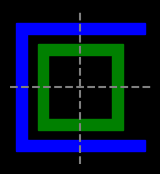

Distance between the outer box (box_cove_a) and the inner box (box_ring_b) is half the inner width of the box_cove_a minus half the outer width of the box_ring_b : 0.50
Shapely distance: 0.5


In [11]:
box6 = shapely.Polygon(box_points(6))
box5 = shapely.Polygon(box_points(width=7, height=5, offset_x=1))
box4 = shapely.Polygon(box_points(4))
box3 = shapely.Polygon(box_points(3))
box2 = shapely.Polygon(box_points(2))

box_cove_a = (box6 - box5)
box_ring_b = box4 - box3

plot_ab(box_cove_a, box_ring_b)
print(f"Distance between the outer box (box_cove_a) and the inner box (box_ring_b) "
      f"is half the inner width of the box_cove_a minus half the outer width of the box_ring_b "
      f": {(5 / 2) - (4 / 2):.2f}")
print("Shapely distance:", shapely.distance(box_cove_a, box_ring_b))


### Disjoint Boxes
![Disjoint Boxes](<../../Images/FreeCAD Images/Disjoint Boxes.png>)

In [12]:
def disjoint_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=20, length=20, offset_z=0,
                                  spacing=slice_spacing)
    # embedded boxes
    left_cube = make_box(roi_num=1, width=2, offset_x=-3,
                         spacing=slice_spacing)
    right_cube = make_box(roi_num=2, width=2, offset_x=3,
                         spacing=slice_spacing)
    # combine the contours
    slice_data = left_cube + right_cube + body
    return slice_data

In [13]:
slice_data = disjoint_boxes_example()
disjoint_structures = StructureSet(slice_data)
structure_a = disjoint_structures.structures[1]
structure_b = disjoint_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()
print(relation_type)
assert relation_type .relation_type == 'DISJOINT'

INFO:structure_set:Adding structure Structure_0 (0)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Disjoint from
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


Relationship: is Disjoint from


### Calculate Distance Metric using StructureSet.calculate_metric()

The `StructureSet.calculate_metric()` method provides a convenient interface for calculating metrics between structure pairs. Here we calculate the minimum distance between the two disjoint boxes.

In [14]:
# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = disjoint_structures.calculate_metric(1, 2, 'minimum_distance')

# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")
print(f"Closest Region Pair: {distance_result.closest_region_pair}")
print(f"Closest Slice: {distance_result.closest_slice}")

# Per-region distances (if multi-region structures)
if distance_result.per_region_minimum_distance:
    print("\nPer-Region Distances:")
    for region_pair, dist in distance_result.per_region_minimum_distance.items():
        print(f"  Region pair {region_pair}: {dist:.2f} cm")

# Expected: Distance should be 4 cm (boxes centered at x=-3 and x=3, each with width 2)
# Distance = 3 - 1 - (1 - (-3)) = 6 - 2 = 4 cm
expected_distance = 4.0
assert abs(distance_result.minimum_distance - expected_distance) < 0.01, \
    f"Expected {expected_distance:.2f} cm, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of {expected_distance:.2f} cm")

INFO:metrics.config:Loading metrics configuration from d:\OneDrive - Queen's University\Python\Projects\StructureRelations\src\metrics\metrics_config.json
INFO:metrics.config:Metrics configuration loaded successfully


Minimum Distance: 4.00 cm
Closest Region Pair: (0, 0)
Closest Slice: (-1.0, -1.0)

Per-Region Distances:
  Region pair (0, 0): 4.00 cm

✓ Distance matches expected value of 4.00 cm


In [15]:
# Examine per-slice distances for detailed analysis
if distance_result.slice_distances:
    print("Per-Slice Distances:")
    for region_pair, slice_dists in distance_result.slice_distances.items():
        print(f"\nRegion pair {region_pair}:")
        for (slice_a, slice_b), dist in sorted(slice_dists.items()):
            print(f"  Slice {slice_a} to {slice_b}: {dist:.2f} cm")

Per-Slice Distances:

Region pair (0, 0):
  Slice -1.0 to -1.0: 4.00 cm
  Slice -1.0 to -0.9: 4.00 cm
  Slice -0.9 to -1.0: 4.00 cm
  Slice -0.9 to -0.9: 4.00 cm
  Slice -0.9 to -0.8: 4.00 cm
  Slice -0.8 to -0.9: 4.00 cm
  Slice -0.8 to -0.8: 4.00 cm
  Slice -0.8 to -0.7: 4.00 cm
  Slice -0.7 to -0.8: 4.00 cm
  Slice -0.7 to -0.7: 4.00 cm
  Slice -0.7 to -0.6: 4.00 cm
  Slice -0.6 to -0.7: 4.00 cm
  Slice -0.6 to -0.6: 4.00 cm
  Slice -0.6 to -0.5: 4.00 cm
  Slice -0.5 to -0.6: 4.00 cm
  Slice -0.5 to -0.5: 4.00 cm
  Slice -0.5 to -0.4: 4.00 cm
  Slice -0.4 to -0.5: 4.00 cm
  Slice -0.4 to -0.4: 4.00 cm
  Slice -0.4 to -0.3: 4.00 cm
  Slice -0.3 to -0.4: 4.00 cm
  Slice -0.3 to -0.3: 4.00 cm
  Slice -0.3 to -0.2: 4.00 cm
  Slice -0.2 to -0.3: 4.00 cm
  Slice -0.2 to -0.2: 4.00 cm
  Slice -0.2 to -0.1: 4.00 cm
  Slice -0.1 to -0.2: 4.00 cm
  Slice -0.1 to -0.1: 4.00 cm
  Slice -0.1 to 0.0: 4.00 cm
  Slice 0.0 to -0.1: 4.00 cm
  Slice 0.0 to 0.0: 4.00 cm
  Slice 0.0 to 0.1: 4.00 cm
  Sl

### Visualize the Disjoint Boxes

Plot a slice to visualize the two disjoint boxes and their separation.

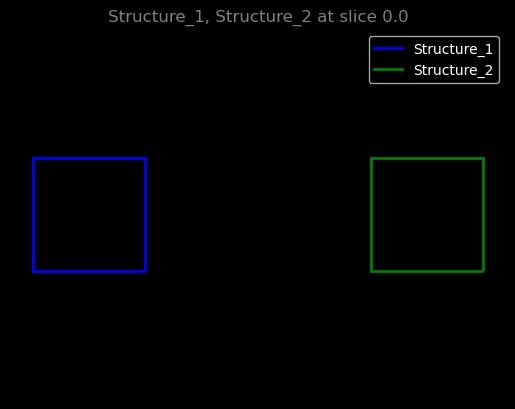


The two boxes are separated by 4.00 cm


In [16]:
# Plot the disjoint boxes on slice 0.0
plot_roi_slice(disjoint_structures, 0.0, roi_list=[1, 2])
print(f"\nThe two boxes are separated by {distance_result.minimum_distance:.2f} cm")

### Access Stored Metric from Relationship Graph

The calculated metric is automatically stored in the relationship graph and can be retrieved later without recalculation.

In [17]:
# Retrieve the relationship from the graph
relationship = disjoint_structures.get_relationship(1, 2)

# Access the RelationshipMetrics object
print("RelationshipMetrics object:")
print(f"  Structure A: {relationship.metrics.structure_a_name} (ROI {relationship.metrics.structure_a_roi})")
print(f"  Structure B: {relationship.metrics.structure_b_name} (ROI {relationship.metrics.structure_b_roi})")
print(f"  Unit: {relationship.metrics.unit}")
print(f"  Region count A: {relationship.metrics.region_count_a}")
print(f"  Region count B: {relationship.metrics.region_count_b}")

# Access the stored distance metric
print("\nStored Distance Metric:")
print(f"  Minimum distance: {relationship.metrics.distance.minimum_distance:.2f} cm")
print(f"  Closest region pair: {relationship.metrics.distance.closest_region_pair}")
print(f"  Closest slice: {relationship.metrics.distance.closest_slice}")

# Verify it's the same object we got from calculate_metric
assert relationship.metrics.distance is distance_result
print("\n✓ Stored metric is the same object returned by calculate_metric()")

# Show serialization to dict (useful for webapp APIs)
print("\nSerialized to dict:")
metrics_dict = relationship.metrics.to_dict()
print(f"  Keys: {list(metrics_dict.keys())}")
print(f"  Distance data: {metrics_dict['distance']}")

RelationshipMetrics object:
  Structure A: Structure_1 (ROI 1)
  Structure B: Structure_2 (ROI 2)
  Unit: cm
  Region count A: 1
  Region count B: 1

Stored Distance Metric:
  Minimum distance: 4.00 cm
  Closest region pair: (0, 0)
  Closest slice: (-1.0, -1.0)

✓ Stored metric is the same object returned by calculate_metric()

Serialized to dict:
  Keys: ['structure_a', 'structure_b', 'unit', 'region_count_a', 'region_count_b', 'distance']
  Distance data: {'minimum_distance': 4.0, 'z_distance': None, 'closest_region': (0, 0)}


### Calculate Multiple Metrics

The RelationshipMetrics object can hold multiple metric types simultaneously. Each metric category has its own dedicated field.

In [18]:
# For a DISJOINT relationship, only distance metrics are applicable
# For a CONTAINS relationship, we could calculate multiple metrics:
#
# margin_result = structure_set.calculate_metric(outer_roi, inner_roi, 'minimum_margin')
# ortho_result = structure_set.calculate_metric(outer_roi, inner_roi, 'orthogonal_margins')
# volume_result = structure_set.calculate_metric(outer_roi, inner_roi, 'volume_overlap')
#
# All would be stored in the same RelationshipMetrics object:
# rel.metrics.margin would have both minimum_margin and orthogonal_margins data
# rel.metrics.volume would have volume overlap data
#
# This provides a complete, organized view of all metrics for the relationship

# Inspect what metric categories are available
rel = disjoint_structures.get_relationship(1, 2)
print("Available metric categories in RelationshipMetrics:")
print(f"  margin: {rel.metrics.margin}")
print(f"  distance: {rel.metrics.distance}")
print(f"  volume: {rel.metrics.volume}")
print(f"  surface: {rel.metrics.surface}")
print(f"  geometry: {rel.metrics.geometry}")
print("\n✓ Only distance is populated because this is a DISJOINT relationship")

Available metric categories in RelationshipMetrics:
  margin: None
  distance: DistanceMetrics(minimum_distance=4.0, per_region_minimum_distance={(0, 0): 4.0}, slice_distances={(0, 0): {(-1.0, -1.0): 4.0, (-1.0, -0.9): 4.0, (-0.9, -1.0): 4.0, (-0.9, -0.9): 4.0, (-0.9, -0.8): 4.0, (-0.8, -0.9): 4.0, (-0.8, -0.8): 4.0, (-0.8, -0.7): 4.0, (-0.7, -0.8): 4.0, (-0.7, -0.7): 4.0, (-0.7, -0.6): 4.0, (-0.6, -0.7): 4.0, (-0.6, -0.6): 4.0, (-0.6, -0.5): 4.0, (-0.5, -0.6): 4.0, (-0.5, -0.5): 4.0, (-0.5, -0.4): 4.0, (-0.4, -0.5): 4.0, (-0.4, -0.4): 4.0, (-0.4, -0.3): 4.0, (-0.3, -0.4): 4.0, (-0.3, -0.3): 4.0, (-0.3, -0.2): 4.0, (-0.2, -0.3): 4.0, (-0.2, -0.2): 4.0, (-0.2, -0.1): 4.0, (-0.1, -0.2): 4.0, (-0.1, -0.1): 4.0, (-0.1, 0.0): 4.0, (0.0, -0.1): 4.0, (0.0, 0.0): 4.0, (0.0, 0.1): 4.0, (0.1, 0.0): 4.0, (0.1, 0.1): 4.0, (0.1, 0.2): 4.0, (0.2, 0.1): 4.0, (0.2, 0.2): 4.0, (0.2, 0.3): 4.0, (0.3, 0.2): 4.0, (0.3, 0.3): 4.0, (0.3, 0.4): 4.0, (0.4, 0.3): 4.0, (0.4, 0.4): 4.0, (0.4, 0.5): 4.0, (0.5, 0.